# Redes Neurais Convolucionais (CNNs)
As CNNs remontam ao estudo do córtex visual do cérebro e têm sido usadas no reconhecimento de imagens desde a década de 1980.

## Arquitetura do córtex visual
Pesquisadores demonstraram que muitos neurônios no córtex visual têm um pequeno campo receptivo local, significando que eles reagem a estímulos visuais localizados em uma região limitada do campo visual. Os campos receptivos de diferentes neurônios podem se sobrepor e, juntos, revestir todo o campo visual.

Esses estudos do córtex visual serviram como inspiração para a neocognitron, que gradativamente evoluiu para as CNNs. O artigo de 1998 de Yann LeCun et al. apresentou a arquitetura LeNet-5, que segue alguns elementos constitutivos que já conhecemos, como camadas interligadas a funções de ativação, e a introdução de dois novos termos: camadas convolucionais e camadas de pooling.

## Camadas convolucionais
A camada convolucional é uma operação matemática que superpõe uma função sobre a outra e calcula a integral de sua multiplicação pontual (não faço ideia como isso funciona, mas é bom saber). Os neurônios na primeira camada convolucional não estão interligados a cada pixel na imagem de entrada (como estavam nas camadas analisadas nos capítulos anteriores), mas somente aos pixels em seus campos receptivos. Em contrapartida, cada neurônio na segunda camada convolucional está interligado apenas a neurônios localizados dentro de um pequeno retângulo na primeira camada.

Para que uma camada tenha a mesma altura e largura da camada anterior, é comum acrescentar zeros ao redor das entradas. Esse procedimento é conhecido como _zero-padding_. É possível interligar uma camada de entrada grande a uma camada muito menor ao espaçar os campos receptivos, o que reduz radicalmente a complexidade computacional do modelo. Isso se chama _stride_.

### Filtros
Os pesos de um neurônio podem ser representados como uma pequena imagem do tamanho do campo receptivo. Um kernel de convolução funciona como uma matriz de filtros que desliza sobre os pixels de uma imagem para extrair características fundamentais. Durante esse movimento, o kernel realiza multiplicações matemáticas entre seus valores internos e a área correspondente da imagem, somando-os para gerar um novo valor que compõe o mapa de características. Esse processo permite que a rede neural identifique elementos essenciais como bordas, texturas e formas geométricas de maneira eficiente e automatizada.

Diferentes configurações de valores dentro do kernel produzem efeitos variados no resultado final, como o realce de contornos ou o desfoque de detalhes irrelevantes. Na prática, kernels especializados em detecção de bordas conseguem isolar o esqueleto visual de um objeto, facilitando o reconhecimento de padrões mais complexos em camadas posteriores do modelo. Essa técnica é a base da visão computacional moderna, pois transforma pixels brutos em informações estruturadas e semanticamente relevantes para a inteligência artificial.

![kernel-de-convolucao.jpeg](chapter-14/images/kernel-de-convolucao.jpeg)

### Empilhando múltiplos mapas de características
Como uma camada convolucional tem diversos filtros e gera como saída um mapa de características por filtro, motivo pela qual é representada com mais precisão em 3D. Ela tem um neurônio por pixel em cada mapa de características, e todos os neurônios em um determinado mapa de características compartilham os mesmos parâmetros (pesos e vieses). Os neurônios em diferentes mapas de características usam parâmetros distintos. O campo receptivo de um neurônio é o mesmo que foi descrito anteriormente e se estende por todos os mapas de características das camadas anteriores.

Resumindo: uma camada convolucional aplica simultâneamente diversos filtros treináveis às entradas, fazendo com que elas consigam detectar características em qualquer lugar de suas entradas.

As imagens de entrada também são compostas de diversas subcamadas, uma por canal de cor (RGB). Pode ter muitos mais canais, por exemplo, imagens de satélite, que pegam também infravermelho. 


### Implementação no TensorFlow
Cada imagem é representada como um tensor 3D [height, width, channels]. Um mini-batch é representado como um tensor 4D [mini-batch size, height, width, channels]. Os pesos de uma camada convolucional são representados como um tensor de formato 4D. Os vieses como um tensor 1D.

2026-03-05 23:18:42.735758: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-05 23:18:42.735789: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-05 23:18:42.735794: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-05 23:18:42.735824: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-05 23:18:42.735832: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


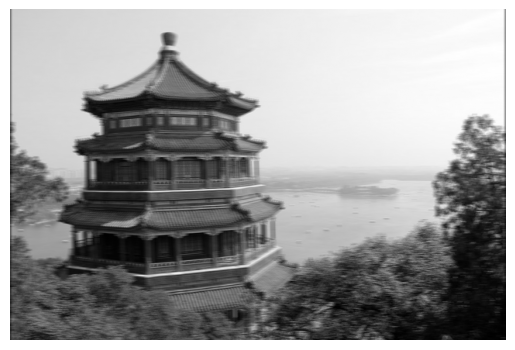

In [ ]:
from sklearn.datasets import load_sample_image
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
keras = tf.keras

china = load_sample_image('china.jpg') / 255
flower = load_sample_image('flower.jpg') / 255
images = np.array([china, flower])
batch_size, height, width, channels = images.shape

# cria dois filtros
filters = np.zeros(shape=(7,7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1
filters[3, :, :, 1] = 1

# Cria dois kernels de convolução 7x7 aplicados a todos os canais RGB.
# O tensor tem formato (altura, largura, canais, nº de filtros).
# Filtro 0: ativa a coluna central → detector de bordas/linhas verticais.
# Filtro 1: ativa a linha central → detector de bordas/linhas horizontais.
# Esses filtros são exemplos manuais de feature detectors usados em CNNs.

outputs = tf.nn.conv2d(images, filters, strides=1, padding='same')

plt.imshow(outputs[0, :, :, 1], cmap='gray')
plt.axis('off')
plt.show()

A linha `tf.nn.conv2d(images, filters, strides=1, padding='same')` aplica a operação de convolução entre o conjunto de imagens e os filtros definidos anteriormente. Cada filtro 7×7 percorre a imagem pixel a pixel (`stride = 1`), calculando o produto escalar entre os valores do kernel e os pixels da região correspondente da imagem. O parâmetro `padding='same'` adiciona preenchimento nas bordas para que a saída tenha a mesma altura e largura da imagem original.

O resultado é armazenado em `outputs`, um tensor com formato `(batch_size, altura, largura, número_de_filtros)`, onde cada filtro gera um **mapa de ativação** que indica onde o padrão aprendido pelo kernel aparece na imagem.

Na visualização, `outputs[0, :, :, 1]` seleciona o mapa de ativação do **segundo filtro** aplicado à **primeira imagem do lote**. Esse mapa é exibido com `plt.imshow(..., cmap='gray')`, onde regiões mais claras indicam locais em que o filtro respondeu com maior intensidade, ou seja, onde o padrão detectado (neste caso, linhas horizontais) está presente na imagem.

Neste exemplo definimos manualmente filtros, mas em uma CNN real normalmente definiríamos os filtros com variáveis treináveis para que a rede neural possa aprender quais filtros funcionam melhor. Em vez de criar manualmente as variáveis, use a camada `keras.layers.Conv2D`

In [ ]:
conv = keras.layers.Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')

feature_maps = conv(images)  # aplica a convolução

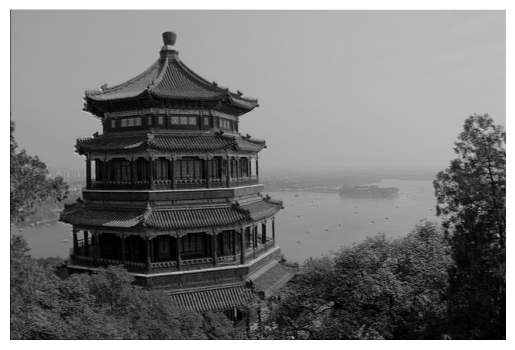

In [35]:
fm = feature_maps[0, :, :, 0].numpy()
plt.imshow((fm - fm.min())/(fm.max()-fm.min()), cmap='gray') # precisa fazer normalização na visualização
plt.axis('off')
plt.show()

# Camadas de Pooling
o objetivo das camadas de pooling é subamostrar (encolhimento) a imagem de entrada para reduzir a carga computacional, o uso de memória e o número de parâmetros (restringindo o risco de overfitting).

O Neurônio de pooling não tem pesos, diferente dos neurônios convolucionais, tudo o que ele faz é agregar as entradas ao usar uma função de agregação como o máximo ou a média. Camada máxima de pooling é o tipo de camada de pooling mais comum. A operação percorre o mapa de ativação em pequenas regiões (ex.: 2×2) e seleciona apenas o maior valor dentro de cada região. 

Resumo geral até agora: A convolução detecta onde um padrão aparece. O max pooling mantém se o padrão apareceu naquela região, sem precisar da posição exata.

A camada máxima de pooling apresenta algumas desvantagens. Primeiro, ela é destrutiva, mesmo com kernel 2x2 e stride de 2, a saída será duas vezes menor em ambas as direções (a área fica quatro vezes menor) e simplesmente perde 75% dos valores de entrada.

## Implementação com TensorFlow
O padrão de strides é o tamanho do kernel, então essa camada usará um stride de 2 (tanto horizontal quanto vertical). Por padrão ele usa o padding como 'valid' (ou seja, nada de padding)

In [36]:
max_pool = keras.layers.MaxPool2D(pool_size=2)

Para criar uma camada média de Pooling, basta usar `AvgPool2D`. A Keras não tem uma camada máxima de pooling de profundidade, mas TensorFlow tem, `tf.nn.max_pool()` e especificar o tamanho do kernel e do stride como 4-tuplas (tuplas de tamanho 4). Os três primeiros valores de cada um deve ser 1. O último valor deve ser qualquer tamanho do kernel e de stride. 

In [40]:
output = tf.nn.max_pool(images, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3), padding='VALID')

# Caso queira incluir a camada em um dos modelos Keras, envolva em uma camada lambda

depth_pool = keras.layers.Lambda(
    lambda X: tf.nn.max_pool(images, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3), padding='VALID')
)

## Camada média de pooling global
Calcula a média do mapa inteiro de características. Isso significa que ela apenas gera a saída de um único número por mapa de características e por instância. É extremamente destrutivo (maioria das informações é perdida), pode ser útil como camada de saída

In [41]:
global_avg_pool = keras.layers.GlobalAvgPool2D()

# Arquitetura das CNNs
Um erro comum na arquitetura de CNNs é usar kernel de convolução muito grandes. Um kernel 5x5 é a mesma coisa que dois 3x3, que faz menos cálculos e terá um melhor desempenho.

In [54]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_val = X_train_full[:5000]
X_train = X_train_full[5000:]

y_val = y_train_full[:5000]
y_train = y_train_full[5000:]

In [55]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [56]:
# Implementação de CNN com Fashion-MNIST
model = keras.models.Sequential([
    keras.layers.Conv2D(64, 7, padding='same', input_shape=[28, 28, 1]), # define 64 filtros 7x7 para extrair padrões espaciais iniciais
    keras.layers.BatchNormalization(), # normaliza as ativações do batch para estabilizar e acelerar o treinamento
    keras.layers.Activation('relu'), # aplica função de ativação não linear
    keras.layers.MaxPooling2D(2), # reduz as dimensões espaciais pela metade (28x28 → 14x14)

    keras.layers.Conv2D(128, 3, padding='same', kernel_initializer="he_normal"), # aumenta o número de filtros para capturar padrões mais complexos
    keras.layers.BatchNormalization(), # normalização para evitar instabilidade nos gradientes
    keras.layers.Activation('relu'), # ativação ReLU

    keras.layers.Conv2D(128, 3, padding='same', kernel_initializer="he_normal"), # outra convolução para refinar as features extraídas
    keras.layers.BatchNormalization(), # normalização das ativações
    keras.layers.Activation('relu'), # ativação não linear
    keras.layers.MaxPooling2D(2), # reduz novamente as dimensões espaciais (14x14 → 7x7)

    keras.layers.Conv2D(256, 3, padding='same', kernel_initializer="he_normal"), # mais filtros para detectar padrões mais abstratos
    keras.layers.BatchNormalization(), # estabiliza o treinamento
    keras.layers.Activation('relu'), # ativação ReLU

    keras.layers.Conv2D(256, 3, padding='same', kernel_initializer="he_normal"), # refina ainda mais os mapas de características
    keras.layers.BatchNormalization(), # normalização
    keras.layers.Activation('relu'), # ativação não linear

    keras.layers.Flatten(), # transforma o tensor 3D (7x7x256) em um vetor 1D para alimentar as camadas densas

    keras.layers.Dense(128), # camada totalmente conectada para combinar as features extraídas
    keras.layers.BatchNormalization(), # normaliza as ativações da camada densa
    keras.layers.Activation('relu'), # função de ativação
    keras.layers.Dropout(0.5), # desativa aleatoriamente 50% dos neurônios para reduzir overfitting

    keras.layers.Dense(64), # segunda camada densa para refinar a representação
    keras.layers.BatchNormalization(), # normalização
    keras.layers.Activation('relu'), # ativação não linear
    keras.layers.Dropout(0.5), # regularização contra overfitting

    keras.layers.Dense(10, activation='softmax'), # camada de saída com 10 classes do Fashion-MNIST
])

In [57]:
optimizer = keras.optimizers.Adam(
    learning_rate=0.0005,
    clipvalue=1.0
)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [58]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 48s 104ms/step - accuracy: 0.7940 - loss: 0.6841 - val_accuracy: 0.7746 - val_loss: 0.6225
Epoch 2/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 48s 111ms/step - accuracy: 0.8775 - loss: 0.4019 - val_accuracy: 0.8976 - val_loss: 0.2884
Epoch 3/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 46s 107ms/step - accuracy: 0.8973 - loss: 0.3262 - val_accuracy: 0.9074 - val_loss: 0.2547
Epoch 4/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9079 - loss: 0.2872 - val_accuracy: 0.9046 - val_loss: 0.2580
Epoch 5/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9162 - loss: 0.2606 - val_accuracy: 0.9092 - val_loss: 0.2442
Epoch 6/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9265 - loss: 0.2295 - val_accuracy: 0.9068 - val_loss: 0.2627
Epoch 7/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9324 - loss: 0.2112 - val_accuracy: 0.9192 - val_loss: 0.2321
Epoch 8/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.9373 - loss: 0

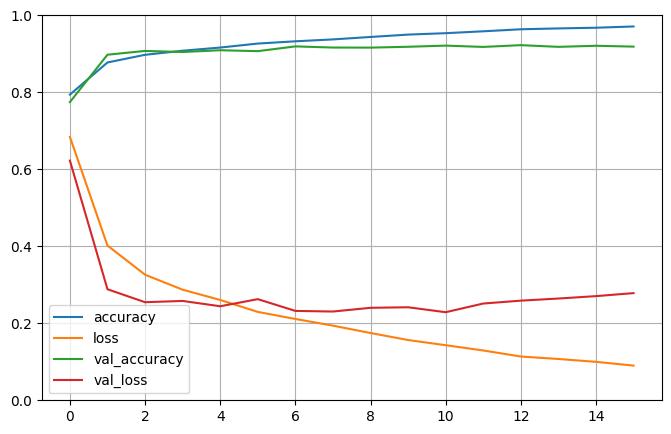

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0, 1) #precisa definir o intervalo vertical para 0 até 1
plt.show()